### Chatbot Reading Existing Memories

In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage,AIMessage
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict,Annotated,List
from langgraph.graph import StateGraph,START,END,add_messages
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
load_dotenv()

model = ChatOpenAI()

In [14]:
class ChatState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]

In [15]:
store = InMemoryStore()
user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Nitish"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [16]:
items = store.search(user_details)
msg = []
for item in items:
    msg.append(item.value['data'])
msg

['Name: Nitish',
 'Profession: Teaches AI on YouTube',
 'Prefers concise answers',
 'Likes examples in Python',
 'Building MCP servers (Python-based project)']

In [27]:
def chat_node(state:ChatState,config:RunnableConfig,store:BaseStore)->dict:

    messages = state.get('messages',[])

    user_id = config['configurable']['user_id']

    user_details = ('user',user_id,'details')

    user_content = []
    items = store.search(user_details)
    for item in items:
        user_content.append(item.value['data'])


    prompt = ChatPromptTemplate([
        ('system',"""You are a helpful assistant with memory capabilities.
        If user-specific memory is available, use it to personalize 
        your responses based on what you know about the user.

        Your goal is to provide relevant, friendly, and tailored 
        assistance that reflects the user’s preferences, context, and past interactions.

        If the user’s name or relevant personal context is available, always personalize your responses by:
            – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
            – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
            – Adjusting the tone to feel friendly, natural, and directly aimed at the user

        Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
        say "Since your project is built with TypeScript..."

        Use personalization especially in:
            – Greetings and transitions
            – Help or guidance tailored to tools and frameworks the user uses
            – Follow-up messages that continue from past context

        Always ensure that personalization is based only on known user details and not assumed.

        In the end suggest 3 relevant further questions based on the current response and user profile

        The user’s memory (which may be empty) is provided as: {user_content}"""),
        ('user',"{messages}")
        ])

    chain = prompt | model

    response = chain.invoke({'user_content':user_content,'messages':messages})

    return {'messages':[response]}
    

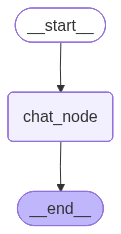

In [28]:
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

store = store

chatbot = graph.compile(store = store)

chatbot

In [32]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

response = chatbot.invoke({'messages':[HumanMessage(content='Tell me something about me?')]},config=config)

print(response['messages'][-1].content)

Sure, Nitish! Based on what I remember about you:
- Your name is Nitish
- You teach AI on YouTube
- You prefer concise answers
- You like examples in Python
- You are building an MCP server, which is a Python-based project

Is there anything specific you would like to know or discuss further?


### Chatbot Creating New Memories

In [2]:
from pydantic import BaseModel,Field
from langchain_core.output_parsers import PydanticOutputParser
import uuid

In [34]:
model = ChatOpenAI()

In [11]:
class Decision(BaseModel,):

    should_store : bool = Field(description="True or False")
    memories : List[str] = Field(default_factory=list,description="Atomic user memories to store")

In [12]:
parser = PydanticOutputParser(pydantic_object=Decision)

In [13]:
class ChatState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]

In [14]:
store = InMemoryStore()

#namespace = ('user',user_id,'details')

In [15]:
def remember(state:ChatState,config = RunnableConfig,store = BaseStore)->dict:

    user_id = config['configurable']['user_id']

    namespace = ('user',user_id,'profile')

    messages = state.get('messages',[]) or []
    last_message = messages[-1].content

    prompt = ChatPromptTemplate([
        ('system',"Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence. \n {format_instruction}"),
                    ('user',"{last_message}")
    ],
    input_variables=['last_message'],
    partial_variables={'format_instruction':parser.get_format_instructions()})

    chain = prompt | model | parser

    decision : Decision = chain.invoke({'last_message':last_message})

    print(decision.should_store)
    print(decision.memories)

    if decision.should_store:
        for msg in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{'data':msg})
    else:
        print('No memory')

    return {'messages':[AIMessage(content=('Noted'))]}
    

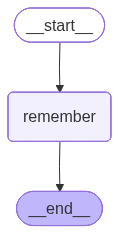

In [16]:
graph = StateGraph(ChatState)

graph.add_node('remember',remember)

graph.add_edge(START,'remember')
graph.add_edge('remember',END)

chatbot = graph.compile(store=store)

chatbot

In [30]:
config = {'configurable':{'user_id':"u1"}}

response = chatbot.invoke({"messages":HumanMessage(content='Alex loves coding in Python and JavaScript and is currently building a smart home system with a Raspberry Pi. Today, Alex drank a cup of green tea and said “Hello” to a colleague in the morning. On weekends, Alex enjoys hiking and often reads science fiction novels before bed. Alex’s favorite music includes jazz and Radiohead. After lunch, Alex was feeling sleepy and even went for a 15-minute walk. Unfortunately, Alex spilled coffee on the keyboard today.')},config=config)

print(response['messages'][-1].content)

True
['Alex loves coding in Python and JavaScript', 'Alex is currently building a smart home system with a Raspberry Pi', 'Alex enjoys hiking on weekends', 'Alex often reads science fiction novels before bed', "Alex's favorite music includes jazz and Radiohead", 'Alex went for a 15-minute walk after feeling sleepy post lunch', 'Unfortunately, Alex spilled coffee on the keyboard today']
Noted


In [31]:
items = store.search(("user", "u1", "profile"))

for item in items:
    print(item.value['data'])

User's name is Nitish
User teaches AI on YouTube
Favorite programming language: Python
User's name is Nitish.
Alex loves coding in Python and JavaScript
Alex is currently building a smart home system with a Raspberry Pi
Alex enjoys hiking on weekends
Alex often reads science fiction novels before bed
Alex's favorite music includes jazz and Radiohead
Alex went for a 15-minute walk after feeling sleepy post lunch


### Chatbot Creating New Memories(without Duplication)

In [3]:
load_dotenv()
store = InMemoryStore()
model = ChatOpenAI()

In [4]:
class Memory(BaseModel):

    is_new : bool = Field(description = "True or False")
    text: str = Field(description="Atomic user memory as a short sentence")


In [5]:
class Decision(BaseModel,):

    should_store : bool = Field(description="True or False")
    memories : List[Memory] = Field(default_factory=list,description="Atomic user memories to store")

parser = PydanticOutputParser(pydantic_object=Decision)

In [6]:
class ChatState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]

In [7]:
def remember(state:ChatState,config:RunnableConfig,store:BaseStore)->dict:

    user_id = config['configurable']['user_id']
    namespace = ('user',user_id,'profile')

    messages  = state['messages']
    last_message = messages[-1].content

    items = store.search(namespace)
    user_details_content = []
    for item in items:
        user_details_content.append(item.value['data'])

    prompt = ChatPromptTemplate([
        ('system',"""You are responsible for updating and maintaining accurate user memory.

            CURRENT USER DETAILS (existing memories):
            {user_details_content}

            TASK:
            - Review the user's latest message.
            - Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
            - For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
            - If it is basically the same meaning as something already present, set is_new=false.
            - Keep each memory as a short atomic sentence.
            - No speculation; only facts stated by the user.
            - If there is nothing memory-worthy, return an empty list. \n {format_instruction}
            """),
        ('user',"{last_message}")
    ],
    input_variables = ['user_details_content','last_message'],
    partial_variables = {'format_instruction':parser.get_format_instructions()}
    )

    chain = prompt | model | parser

    decision :Decision = chain.invoke({'user_details_content':user_details_content,'last_message':last_message})

    print(decision.should_store)
    print(decision.memories)

    if decision.should_store:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{'data':mem})

    return {'messages':[AIMessage(content = 'Noted')]}

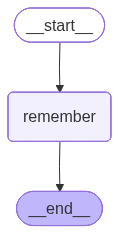

In [8]:
graph = StateGraph(ChatState)

graph.add_node('remember',remember)

graph.add_edge(START,'remember')
graph.add_edge('remember',END)

chatbot = graph.compile(store=store)

chatbot

In [19]:
config = {'configurable':{'user_id':'u1'}}

response = chatbot.invoke({'messages':[HumanMessage(content='I like python')]},config = config)

print(response['messages'][-1].content)

False
[]
Noted


In [20]:
user_id = config['configurable']['user_id']
namespace = ('user',user_id,'profile')

items = store.search(namespace)
for item in items:
    print(item.value['data'])

is_new=True text="User's name is Nitish."
is_new=True text='User likes Python for programming.'
is_new=True text="User's full name is Nitish Kumar Singh."
